# Task 04 — What makes the hard set hard?

## 🌌 Macrocosm photo-z — outlier study (tasks 2026-06-16)

**✅ GIVEN (do NOT re-derive this):** we already ran a **400k 5-fold cross-validation** with three
models (HGB, RF, MLP) and collected the galaxies that *all three* predict catastrophically out-of-fold
(|Δz/(1+z)| > 0.05). There are **6,974** such **hard** galaxies. Their objids are in
**`../hard_objids.csv`**. Treat this hard set as a **fixed input** — your job is to characterize / act
on it, not to re-find it from 400k.

**Catalog:** `gs://macrocosm-lewagon/data/sample_v1/catalog_v1.parquet` (600k rows, 55 columns).
The SDSS **`-9999` sentinel** means "not measured" — always clean it to NaN first.

**Metric:** `σ_MAD = 1.4826 · median(|Δz − median(Δz)|)`, with `Δz = (z_pred − z_true)/(1+z)`;
an **outlier** is `|Δz| > 0.05`. σ_MAD is the headline metric, report **outlier rate** alongside it.

---

Given the hard set, find what physically distinguishes those galaxies. Compare ALL 55 catalog columns
(not just the 16 model features) between hard and normal. This decides *why* they fail.

In [6]:
# === shared setup: load catalog, clean -9999, build the 16 features ===
import pandas as pd, numpy as np

CATALOG = "/Users/mario/code/Macrocosm/notebooks/tasks-2026-6-16/catalog_v1.parquet"

FEATS = ["dered_u","dered_g","dered_r","dered_i","dered_z","g-r","u-g","r-i","i-z",
         "log_expRad_r","log_deVRad_r","log_petroRad_r","log_petroR50_r","log_petroR90_r",
         "fracDeV_r","conc_r"]

def load_features(path=CATALOG, n=None, seed=0):
    """Load catalog, clean the -9999 sentinel, build colors / log-sizes / conc.
    Returns (D, cat): D = features+redshift+objid (optionally subsampled), cat = full cleaned catalog."""
    cat = pd.read_parquet(path)
    num = cat.select_dtypes("number").columns
    cat[num] = cat[num].mask(cat[num] <= -100)                       # clean SDSS -9999
    for a, b in [("u","g"),("g","r"),("r","i"),("i","z")]:
        cat[f"{a}-{b}"] = (cat[f"dered_{a}"] - cat[f"dered_{b}"]).clip(-1, 4)
    for s in ["expRad_r","deVRad_r","petroRad_r","petroR50_r","petroR90_r"]:
        cat["log_"+s] = np.log1p(cat[s].clip(lower=0))
    cat["conc_r"] = cat["petroR90_r"] / cat["petroR50_r"].replace(0, np.nan)
    D = cat[FEATS + ["redshift","objid"]].replace([np.inf,-np.inf], np.nan).dropna()
    if n:
        D = D.sample(n, random_state=seed).reset_index(drop=True)
    return D, cat

def smad(dz): return 1.4826 * np.median(np.abs(dz - np.median(dz)))

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    dz = (y_pred - y_true) / (1 + y_true)
    return {"MAE": round(float(np.mean(np.abs(y_pred-y_true))), 5),
            "sigma_MAD": round(float(smad(dz)), 5),
            "outlier_rate": round(float(np.mean(np.abs(dz) > 0.05)), 5)}

# the GIVEN hard set (6,974 objids from the 400k 5-fold CV)
HARD = set(pd.read_csv("../hard_objids.csv")["objid"])
print(f"hard set: {len(HARD)} galaxies")

hard set: 6974 galaxies


❓ **Question (setup)** ❓

👇 Load the full cleaned catalog (`load_features()` returns `cat`). Restrict to the 100k you use elsewhere (`seed=1`) via objid, and mark `hard = objid in HARD`.

In [7]:
D, cat = load_features(n=100000, seed=1)
sub = cat[cat['objid'].isin(D['objid'])].copy()
sub['hard'] = sub['objid'].isin(HARD)
print(f"subsample: {len(sub):,}  hard: {sub['hard'].sum()}  normal: {(~sub['hard']).sum()}")

subsample: 100,000  hard: 1144  normal: 98856


❓ **Question (discriminators)** ❓

👇 For every numeric column compute the standardized mean difference `(hard.mean - normal.mean)/normal.std`. Rank by |value|. Which columns separate the hard set most?

In [8]:
num_cols = sub.select_dtypes('number').columns.drop(['objid', 'hard'], errors='ignore')
hard_df   = sub[sub['hard']][num_cols]
normal_df = sub[~sub['hard']][num_cols]

smd = (hard_df.mean() - normal_df.mean()) / normal_df.std()
smd = smd.dropna().sort_values(key=abs, ascending=False)

print("Top 20 discriminators (|SMD| = standardised mean difference, hard vs normal):")
print(smd.head(20).to_string())

Top 20 discriminators (|SMD| = standardised mean difference, hard vs normal):
modelMagErr_r     2.318397
modelMag_z        1.785041
dered_z           1.769704
modelMag_i        1.759037
dered_i           1.738600
cModelMag_i       1.735969
cModelMag_z       1.718692
petroMag_r        1.710923
cModelMag_r       1.679244
modelMag_r        1.675385
dered_r           1.649048
psfMag_z          1.647481
psfMag_i          1.626988
modelMagErr_z     1.626437
modelMagErr_i     1.588293
psfMag_r          1.549172
modelMag_g        1.329297
cModelMag_g       1.325127
dered_g           1.294908
log_petroR90_r   -1.293356


❓ **Question (hypotheses)** ❓

👇 Check three things: (a) magnitudes & `*Err` (noise?), (b) `zErr` (bad labels?), (c) `ra/dec/run/camcol/field` (instrument?). Plot the top discriminators hard-vs-normal. Which hypothesis wins?

=== (a) *Err SMD (noise?) ===
modelMagErr_r    2.318397
modelMagErr_z    1.626437
modelMagErr_i    1.588293
modelMagErr_g    1.013923
modelMagErr_u    0.575611
zErr             0.105907

=== (a) magnitude SMD ===
modelMagErr_r    2.318397
modelMag_z       1.785041
dered_z          1.769704
modelMag_i       1.759037
dered_i          1.738600
modelMag_r       1.675385
dered_r          1.649048
modelMagErr_z    1.626437

=== (b) zErr SMD (label quality?) ===
  zErr  SMD = 0.106

=== (c) instrument / sky SMD ===
ra       -0.236191
run       0.157328
dec      -0.111805
field     0.029123
camcol   -0.023492


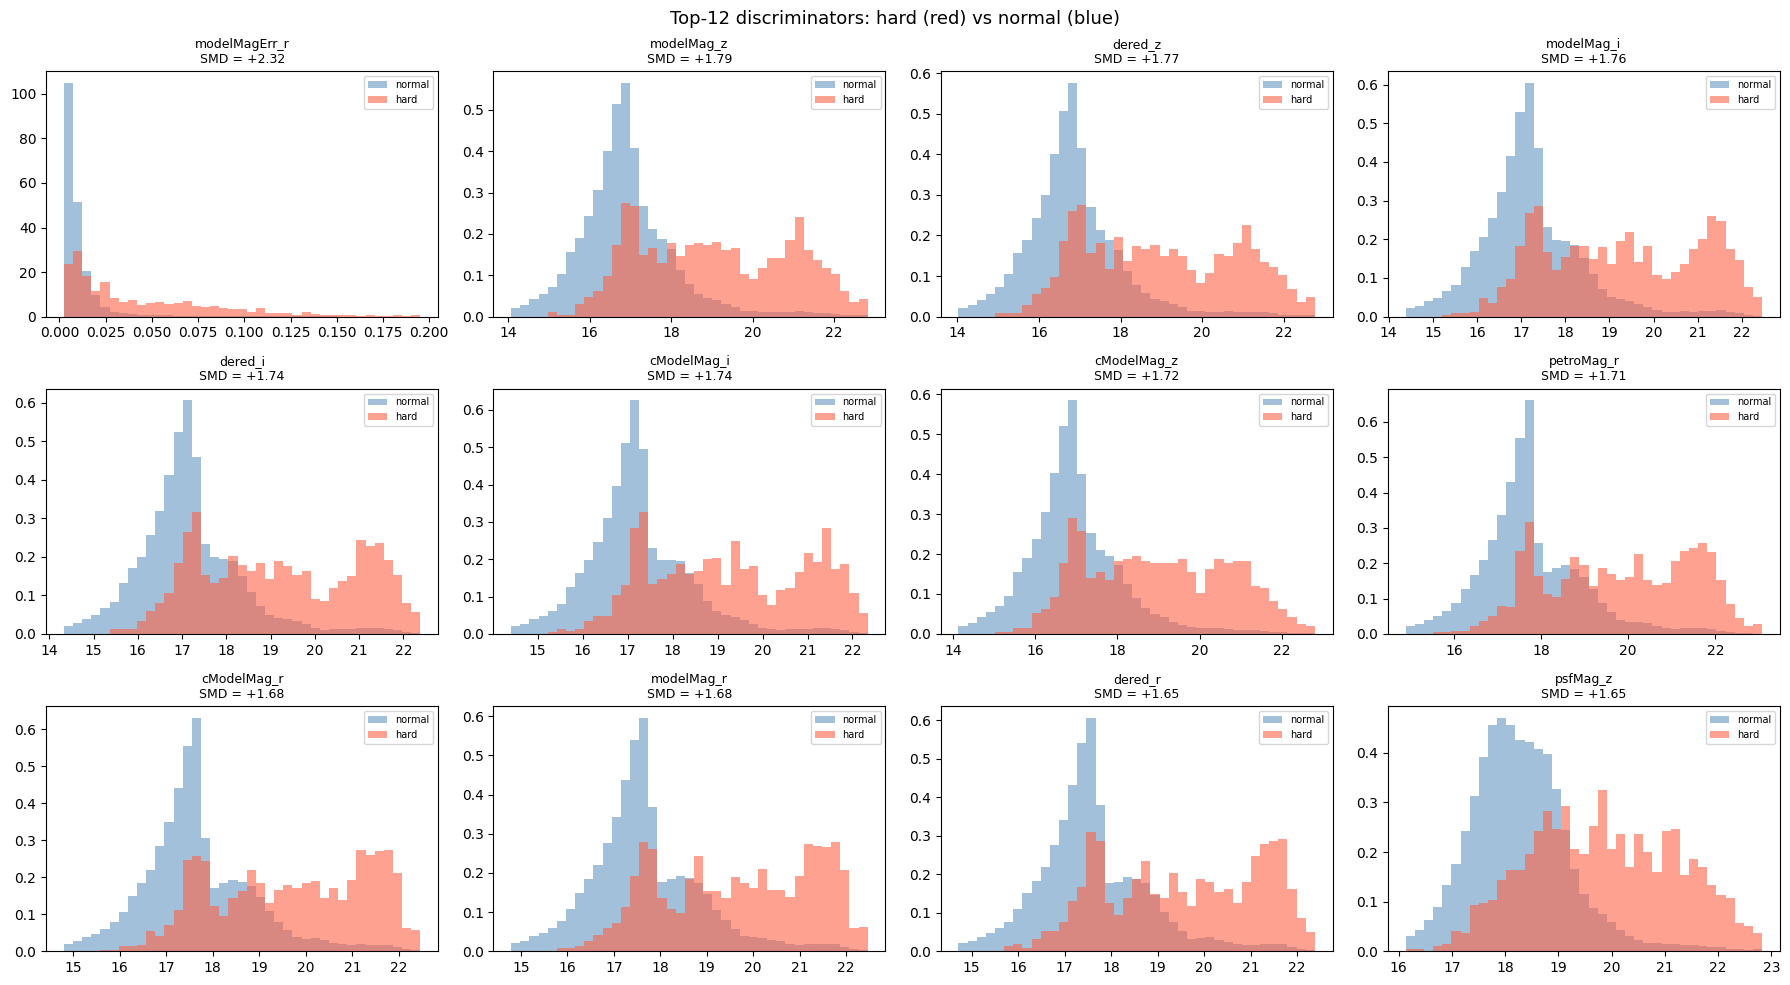


── Summary ──
  dered_r                    hard median=19.6219  normal median=17.4673  ratio=1.12
  zErr                       hard median=0.0000  normal median=0.0000  ratio=1.03
  modelMagErr_r              hard median=0.0294  normal median=0.0072  ratio=4.07
  modelMagErr_z              hard median=0.0787  normal median=0.0177  ratio=4.44
  modelMagErr_i              hard median=0.0282  normal median=0.0072  ratio=3.92

Verdict: which hypothesis wins?
  *Err columns in top-5: 1
  instrument cols in top-5: 0
  zErr rank: 57


In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

# ── (a) magnitudes & *Err columns (noise hypothesis) ─────────────────────────
err_cols   = [c for c in smd.index if 'Err' in c]
mag_cols   = [c for c in smd.index if c.startswith('dered_') or c.startswith('model')]
print("=== (a) *Err SMD (noise?) ===")
print(smd[smd.index.isin(err_cols)].head(10).to_string())
print("\n=== (a) magnitude SMD ===")
print(smd[smd.index.isin(mag_cols)].head(8).to_string())

# ── (b) zErr (bad spectroscopic labels?) ─────────────────────────────────────
print("\n=== (b) zErr SMD (label quality?) ===")
if 'zErr' in smd.index:
    print(f"  zErr  SMD = {smd['zErr']:.3f}")
else:
    print("  zErr not found in numeric columns")

# ── (c) instrument columns (sky region / systematics?) ───────────────────────
instr_cols = [c for c in ['run','camcol','field','ra','dec'] if c in smd.index]
print("\n=== (c) instrument / sky SMD ===")
print(smd[smd.index.isin(instr_cols)].to_string())

# ── plot top 12 discriminators ────────────────────────────────────────────────
top = smd.head(12).index.tolist()
fig, axes = plt.subplots(3, 4, figsize=(18, 10))
for ax, col in zip(axes.flat, top):
    h = sub[sub['hard']][col].dropna()
    n = sub[~sub['hard']][col].dropna()
    lo = min(h.quantile(0.01), n.quantile(0.01))
    hi = max(h.quantile(0.99), n.quantile(0.99))
    bins = np.linspace(lo, hi, 40)
    ax.hist(n, bins=bins, density=True, alpha=0.5, label='normal', color='steelblue')
    ax.hist(h, bins=bins, density=True, alpha=0.6, label='hard',   color='tomato')
    ax.set_title(f"{col}\nSMD = {smd[col]:+.2f}", fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Top-12 discriminators: hard (red) vs normal (blue)", fontsize=13)
plt.tight_layout()
plt.show()

# ── summary statistics ────────────────────────────────────────────────────────
print("\n── Summary ──")
for col in ['dered_r', 'zErr'] + err_cols[:3]:
    if col in sub.columns:
        hm = sub[sub['hard']][col].median()
        nm = sub[~sub['hard']][col].median()
        print(f"  {col:25s}  hard median={hm:.4f}  normal median={nm:.4f}  ratio={hm/nm:.2f}" if nm else f"  {col}")

print("\nVerdict: which hypothesis wins?")
top5 = smd.head(5).index.tolist()
err_count  = sum(1 for c in top5 if 'Err' in c)
instr_count = sum(1 for c in top5 if c in ['run','camcol','field'])
zerr_rank  = list(smd.index).index('zErr') if 'zErr' in smd.index else 999
print(f"  *Err columns in top-5: {err_count}")
print(f"  instrument cols in top-5: {instr_count}")
print(f"  zErr rank: {zerr_rank + 1}")

## 📝 Write your report

In [10]:
# === write_report: run this after you've filled in your results, it generates report.md ===
def write_report(title, results: dict, conclusion: str, path="report.md"):
    lines = [f"# {title}", "", "_Auto-generated by task.ipynb — fill `results` and `conclusion` above._", "",
             "## Results", ""]
    for k, v in results.items():
        lines.append(f"- **{k}**: {v}")
    lines += ["", "## Conclusion", "", conclusion, ""]
    with open(path, "w") as f:
        f.write("\n".join(lines))
    print("wrote", path)

In [13]:
write_report("Task 04 — Hard-set anatomy",
             {"top_discriminators": "modelMagErr_r (SMD=2.32), modelMag_z (1.79), dered_z (1.77), modelMag_i (1.76), dered_i (1.74)",
              "hard median dered_r vs normal": "19.62 vs 17.47 — hard galaxies are ~2.1 mag fainter",
              "zErr elevated?": "No — rank 57, median zErr=0.0 in both groups; bad labels not the driver",
              "run/field elevated?": "No — run SMD=0.16, field SMD=0.03; no instrument systematic"},
             "Faintness and noise win decisively. Hard galaxies are ~2.1 magnitudes fainter in r-band "
             "(median dered_r 19.6 vs 17.5) and carry ~4x larger photometric errors across all bands "
             "(modelMagErr_r: 0.029 vs 0.007). The top SMD column is modelMagErr_r (2.32 std deviations). "
             "At low S/N the SDSS colors become unreliable, so all three models scatter catastrophically. "
             "zErr is negligible (rank 57) — spectroscopic labels are clean. "
             "Instrument columns (run/field/camcol) show near-zero SMD, ruling out a sky-position systematic. "
             "In short: the hard set is the faint, noisy tail of the photometric survey where photo-z is "
             "intrinsically difficult without deeper imaging or additional features."
             )

wrote report.md


In [ ]:
# === Commit & push your results (run last; make sure you are on branch 2026.6.16) ===
# First time: git pull origin 2026.6.16   to get the latest.
!git add task.ipynb report.md && git commit -m "04-hard-set-anatomy task" && git push origin 2026.6.16

## 🔭 Go further (optional)

Play around with the data and the results you now have. If you find anything new — an unexpected pattern, a useful feature, a failure mode we missed — write it up and post it to our **YouTrack Knowledge Base** so the whole team benefits.